# Spikes Interpolation Playground
This playground illustrates the functionality of the SpikesInterpolator for binning and visualizing synthetic spike data.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/goirik-chakrabarty/experanto/blob/clean-spikeinterpolator/examples/playground_spike.ipynb)

## 1. Environment Setup
First, import the necessary libraries for data handling, performance monitoring, and visualization.

In [ ]:
# Install dependencies
!pip install experanto git+https://github.com/sensorium-competition/experanto.git
# !pip install experanto git+https://github.com/goirik-chakrabarty/experanto.git@clean-spikeinterpolator
!pip install dandi pynwb numpy numba matplotlib PyYAML
!pip install hydra-core --upgrade

In [1]:
import numpy as np
import yaml
import tempfile
import shutil
from pathlib import Path
import time
from experanto.interpolators import SpikesInterpolator
import matplotlib.pyplot as plt

## 2. Data Generation Utility
The `create_spikes_data` function simulates a physiological recording. It creates a temporary directory containing:
* `spikes.npy`: A unique NumPy binary file containing a flat array of concatenated spike times.
* `meta.yml`: Metadata defining neuron indices, sampling rates, and recording duration.

### Data Storage Format:
The spike data must be stored in a `.npy` file named `spikes.npy`
(dtype: float64) inside the `root_folder`.

The array contains the actual continuous spike timings (e.g., in seconds).
The timings must be **blocked by neuron**, and within each neuron's block,
the spike times must be **sorted in ascending chronological order**.

A `meta.yml` file in the same folder must provide a `spike_indices` list.
This list defines the start and end indices for each neuron's block in
the flat array. For example, if neuron 0 has 50 spikes and neuron 1 has 30
spikes, `spike_indices` should be `[0, 50, 80]`.

You can create dummy data in the folder of your choice to see how the data needs to look.

In [2]:
# ==========================================
# 1. DATA GENERATION & TESTING
# ==========================================


def create_spikes_data(
    folder_path, n_neurons=50, duration=100.0, rate=20.0, use_mem_mapped=False
):
    """Creates synthetic spike data and metadata."""
    folder = Path(folder_path)
    folder.mkdir(parents=True, exist_ok=True)

    all_spikes_list = []
    indices = [0]

    # Generate random sorted spikes for each neuron
    for _ in range(n_neurons):
        # Sample a distinct firing rate for this neuron
        # (e.g., uniform distribution between 20% and 180% of the base rate)
        neuron_rate = np.random.uniform(0.2 * rate, 1.8 * rate)
        n_spikes = int(duration * neuron_rate)

        # Handle the edge case where a neuron might not fire at all
        if n_spikes == 0:
            spikes = np.array([], dtype=np.float64)
        else:
            # Uniform distribution of spikes, sorted
            spikes = np.sort(np.random.uniform(0, duration, n_spikes))

        all_spikes_list.append(spikes)
        indices.append(indices[-1] + len(spikes))

    # Flatten and save to binary file (replicating real data structure)
    flat_spikes = np.concatenate(all_spikes_list)

    if use_mem_mapped:
        # Create memmap file
        fp = np.memmap(
            folder / "data.mem",
            dtype="float64",
            mode="w+",
            shape=flat_spikes.shape,
        )
        fp[:] = flat_spikes[:]
        fp.flush()
        del fp
    else:
        np.save(
            folder / "spikes.npy", flat_spikes
        )  # Save in .npy format for easier loading

    meta = {
        "modality": "spikes",
        "n_signals": n_neurons,
        "spike_indices": indices,
        "start_time": 0.0,
        "end_time": duration,
        "sampling_rate": 1000.0,  # Arbitrary for spikes, but required by some loaders
    }

    if use_mem_mapped:
        meta["is_mem_mapped"] = True
        meta["dtype"] = "float64"

    with open(folder / "meta.yml", "w") as f:
        yaml.safe_dump(meta, f)

    return all_spikes_list, flat_spikes, indices

## 3. Test Runner: Alignment and Speed
This section runs a rigorous battery of tests. For each of the three alignment modes, it verifies that the interpolator correctly counts spikes within the specified window:
* **Center**: The window spans `[query_time - window/2, query_time + window/2)`.
* **Left**: The window spans `[query_time, query_time + window)`.
* **Right**: The window spans `[query_time - window, query_time)`. *Ideal for causal modeling.*

The runner also calculates **Queries Per Second (QPS)** to demonstrate the efficiency of the underlying implementation.

In [5]:
# ==========================================
# 3. TEST RUNNER (ALIGNMENT + SPEED)
# ==========================================

temp_dir = tempfile.mkdtemp()

try:
    print(f"Test Environment: {temp_dir}")
    gt_spikes_list, gt_flat, gt_indices = create_spikes_data(
        temp_dir, n_neurons=500, duration=1000.0
    )

    # Define query times (randomly sampled)
    n_queries = 1000
    query_times = np.sort(np.random.uniform(1.0, 999.0, size=n_queries))
    window_size = 0.5

    # alignments_to_test = ["center"]
    alignments_to_test = ["center", "left", "right"]

    print(f"\n{'='*60}")
    print(f"STARTING TESTS: {n_queries} queries, Window={window_size}s")
    print(f"{'='*60}")

    for align in alignments_to_test:
        print(f"\n>>> Testing Alignment: {align.upper()}")

        # 1. Instantiate
        interpolator = SpikesInterpolator(
            temp_dir,
            interpolation_window=window_size,
            interpolation_align=align,
            # smoothing_sigma=3.0,

        )

        # 2. Run & Time
        # Warmup (optional, to compile JIT)
        _ = interpolator.interpolate(query_times[:10])

        start_t = time.perf_counter()
        counts, valid = interpolator.interpolate(query_times, return_valid=True)
        end_t = time.perf_counter()

        duration_sec = end_t - start_t
        speed_qps = n_queries / duration_sec

        print(f"Time: {duration_sec*1000:.2f} ms")
        print(f"Speed: {speed_qps:.0f} queries/sec")

        # 3. Verify Correctness
        print("Verifying accuracy...")
        errors = 0
        big_errors = 0
        total_checks = 0

        for t_idx, t in enumerate(query_times):
            # Adjust ground truth logic based on alignment
            if align == "center":
                t_start = t - window_size / 2
                t_end = t + window_size / 2
            elif align == "left":
                t_start = t
                t_end = t + window_size
            elif align == "right":
                t_start = t - window_size
                t_end = t

            for n_idx in range(len(gt_spikes_list)):
                total_checks += 1
                neuron_spikes = gt_spikes_list[n_idx]
                # Ground truth count
                manual_count = np.sum(
                    (neuron_spikes >= t_start) & (neuron_spikes < t_end)
                )

                numba_count = counts[t_idx, n_idx]

                if manual_count != numba_count:
                    # Print only the first error to avoid spamming
                    if errors % 10 == 0:
                        print(
                            f"Mismatch at time {t:.2f}, neuron {n_idx}: Expected {manual_count}, got {numba_count}"
                        )
                    errors += 1
                    if abs(manual_count - numba_count) > 1:
                        big_errors += 1

        if errors == 0:
            print("SUCCESS: All counts match.")
        else:
            print(
                f"FAILED: {errors}/{total_checks} mismatches found. {errors/total_checks*100:.2f}%"
            )
            print(f"Large Errors (>1 count difference): {big_errors}")

finally:
    shutil.rmtree(temp_dir)
    print(f"\n{'='*60}")
    print("Cleanup complete.")

Test Environment: /mnt/lustre-grete/tmp/u18196/tmpw8ojs093

STARTING TESTS: 1000 queries, Window=0.5s

>>> Testing Alignment: CENTER
Time: 21.90 ms
Speed: 45667 queries/sec
Verifying accuracy...
SUCCESS: All counts match.

>>> Testing Alignment: LEFT
Time: 21.33 ms
Speed: 46891 queries/sec
Verifying accuracy...
SUCCESS: All counts match.

>>> Testing Alignment: RIGHT
Time: 29.25 ms
Speed: 34183 queries/sec
Verifying accuracy...
SUCCESS: All counts match.

Cleanup complete.


## 4. Visualization of Alignment Modes
This final section provides a visual comparison. By plotting a raw spike raster alongside heatmaps generated by each alignment mode, you can see how the windowing logic transforms discrete irregular events into continuous-like regular data. Use this to ensure your chosen alignment matches your experimental design (e.g., ensuring a stimulus at time $t$ only affects bins after time $t$).

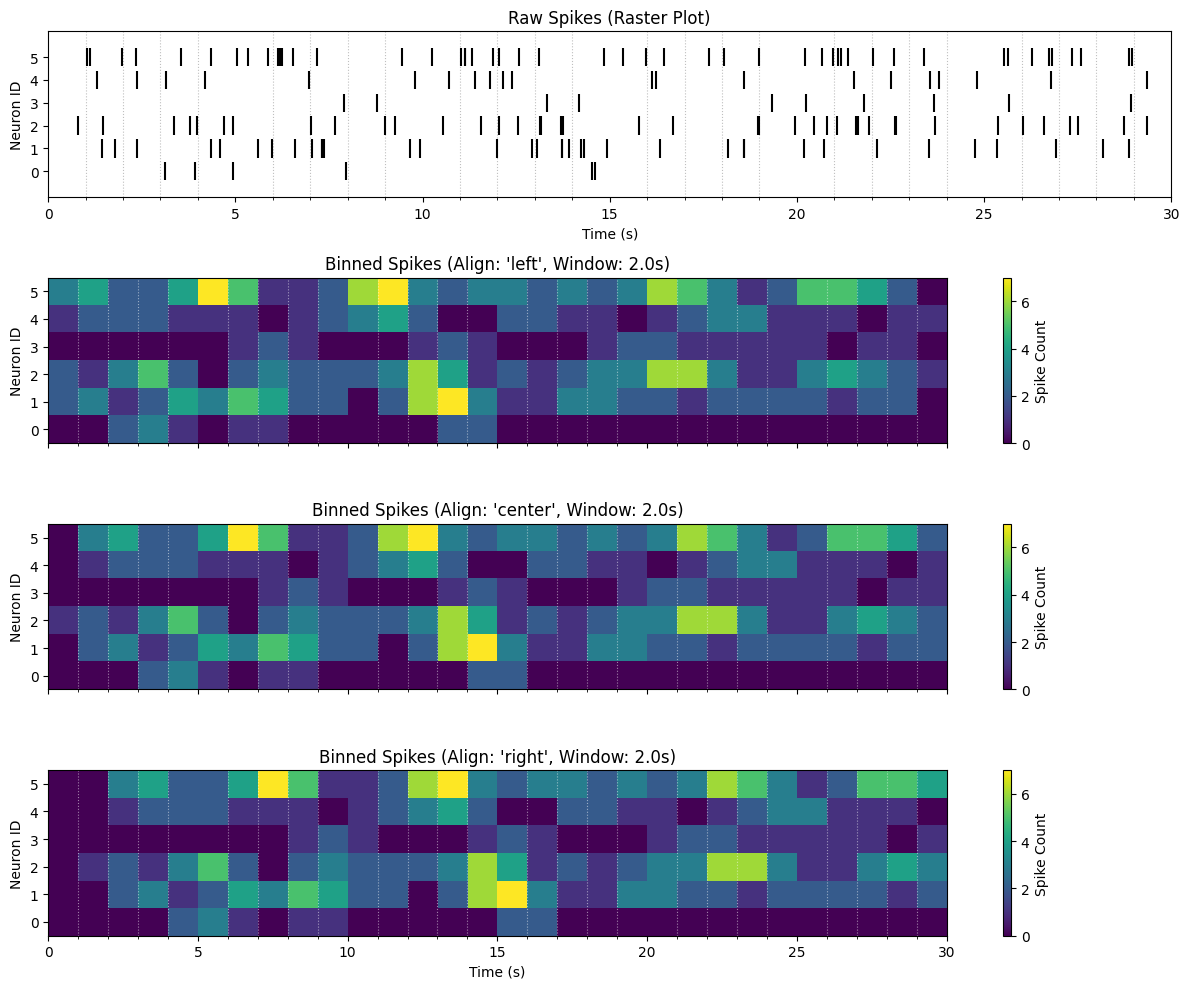

In [7]:
# Create a temporary directory for the dummy data
temp_dir = tempfile.mkdtemp()

try:
    # 1. Generate small dummy dataset (6 neurons, 30 seconds duration)
    duration = 30.0
    n_neurons = 6
    rate = 1.0  # Approx 1 spike per second per neuron
    
    # Reusing the create_spikes_data function
    gt_spikes_list, gt_flat, gt_indices = create_spikes_data(
        temp_dir, n_neurons=n_neurons, duration=duration, rate=rate
    )

    # 2. Define Query Times & Window
    # We query at exactly every 1.0 second, with a 2.0s window to emphasize differences
    query_times = np.arange(0.0, duration, 1.0)
    window_size = 2.0

    # 3. Get Interpolated Bins for each mode
    modes = ["left", "center", "right"]
    binned_data = {}
    
    for align in modes:
        interp = SpikesInterpolator(
            temp_dir, 
            interpolation_window=window_size, 
            interpolation_align=align,
            cache_data=True  # Eagerly load to RAM
        )
        counts, valid = interp.interpolate(query_times, return_valid=True)
        binned_data[align] = counts

    # 4. Visualization
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    # A) Raster plot of raw spikes
    axes[0].eventplot(gt_spikes_list, color='black', linelengths=0.8)
    axes[0].set_title("Raw Spikes (Raster Plot)")
    axes[0].set_ylabel("Neuron ID")
    axes[0].set_yticks(range(n_neurons))
    axes[0].set_xlim(0, duration)
    
    # Add x_label and x_ticks specifically to the raster plot
    axes[0].set_xlabel("Time (s)")
    axes[0].tick_params(labelbottom=True)  # Forces labels to show despite sharex=True
    axes[0].set_xticks(query_times, minor=True)
    axes[0].grid(which='minor', axis='x', color='gray', linestyle=':', alpha=0.5)

    # B) Heatmaps of binned counts
    for idx, align in enumerate(modes):
        ax = axes[idx + 1]
        
        # Transpose counts so y-axis is neurons and x-axis is time
        # extent=[min_x, max_x, min_y, max_y] aligns the heatmap blocks with the time axis
        im = ax.imshow(
            binned_data[align].T, 
            aspect='auto', 
            origin='lower', 
            cmap='viridis', 
            extent=[0, duration, -0.5, n_neurons - 0.5]
        )
        
        ax.set_title(f"Binned Spikes (Align: '{align}', Window: {window_size}s)")
        ax.set_ylabel("Neuron ID")
        ax.set_yticks(range(n_neurons))
        
        # Add a subtle grid to show the queried time bins
        ax.set_xticks(query_times, minor=True)
        ax.grid(which='minor', color='white', linestyle=':', alpha=0.5)
        
        fig.colorbar(im, ax=ax, label="Spike Count")

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

finally:
    # Clean up the temporary directory
    shutil.rmtree(temp_dir)